# Follow Factor Calculation

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import powerlaw

In [2]:
# import datasets
df = pd.read_json("../../Datasets/voluntariosdanavalencia_old.json") # Import data from Voluntarios de Valencia groupchat.

## Global Fano Factor

In [3]:
# Obtain waiting times
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df['waiting_time'] = df['date'].diff().dt.total_seconds() 



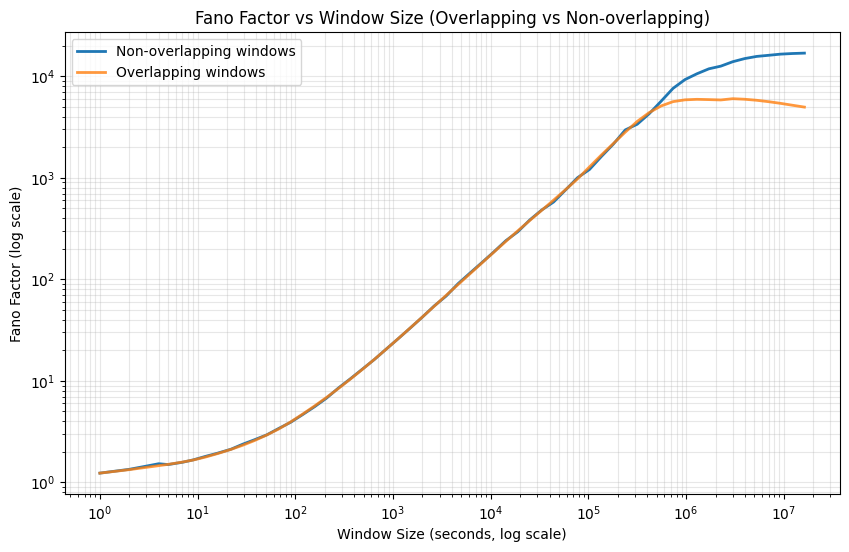

In [4]:
# Fano factor with both non-overlapping and overlapping windows
bin_size = '1s'  # Base time bin for event counts.
counts_per_bin = df.set_index('date').resample(bin_size).size().astype(float)

# Candidate window sizes expressed as number of base bins.
max_window = max(2, len(counts_per_bin) // 2)
window_sizes = np.unique(
    np.logspace(0, np.log10(max_window), 60).astype(int)
)

fano_non_overlapping = []
fano_overlapping = []
valid_windows = []

for window in window_sizes:
    if window < 1:
        continue

    # Overlapping windows: rolling sums with step=1 bin.
    overlap_counts = counts_per_bin.rolling(window=window).sum().dropna()
    mean_overlap = overlap_counts.mean()
    var_overlap = overlap_counts.var(ddof=1) if len(overlap_counts) > 1 else np.nan
    f_overlap = var_overlap / mean_overlap if mean_overlap > 0 else np.nan

    # Non-overlapping windows: sum disjoint blocks of size=window.
    n_blocks = len(counts_per_bin) // window
    if n_blocks > 1:
        trimmed = counts_per_bin.iloc[: n_blocks * window].to_numpy()
        non_overlap_counts = trimmed.reshape(n_blocks, window).sum(axis=1)
        mean_non_overlap = non_overlap_counts.mean()
        var_non_overlap = non_overlap_counts.var(ddof=1)
        f_non_overlap = var_non_overlap / mean_non_overlap if mean_non_overlap > 0 else np.nan
    else:
        f_non_overlap = np.nan

    valid_windows.append(window)
    fano_overlapping.append(f_overlap)
    fano_non_overlapping.append(f_non_overlap)

# Window sizes are in seconds because bin_size='1s'.
window_seconds = np.array(valid_windows)

plt.figure(figsize=(10, 6))
plt.plot(window_seconds, fano_non_overlapping, label='Non-overlapping windows', linewidth=2)
plt.plot(window_seconds, fano_overlapping, label='Overlapping windows', linewidth=2, alpha=0.8)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Window Size (seconds, log scale)')
plt.ylabel('Fano Factor (log scale)')
plt.title('Fano Factor vs Window Size (Overlapping vs Non-overlapping)')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

In [5]:
# Numeric comparison table: overlapping vs non-overlapping
comparison_df = pd.DataFrame({
    'window_seconds': window_seconds,
    'fano_non_overlapping': fano_non_overlapping,
    'fano_overlapping': fano_overlapping
})

comparison_df['overlap_to_non_overlap_ratio'] = (
    comparison_df['fano_overlapping'] / comparison_df['fano_non_overlapping']
    )

# Keep only finite values for clearer reporting.
comparison_df_clean = comparison_df.replace([np.inf, -np.inf], np.nan).dropna()

# Show a compact summary sampled across scales.
sampled = comparison_df_clean.iloc[np.linspace(0, len(comparison_df_clean) - 1, 12, dtype=int)]
display(sampled.round(4))

,window_seconds,fano_non_overlapping,fano_overlapping,overlap_to_non_overlap_ratio
0,1,1.2346,1.2346,1.0000
5,7,1.5793,1.5861,1.0043
10,29,2.3798,2.3241,0.9766
15,119,4.6548,4.7096,1.0118
20,488,13.0941,13.0244,0.9947
25,1994,42.4154,42.5049,1.0021
31,10790,186.7959,185.5630,0.9934
36,44067,578.1519,603.6044,1.0440
41,179962,2146.9143,2176.0342,1.0136
46,734934,7608.3031,5629.3967,0.7399


Central-region power law: F(w) = 0.07021 * w^0.8489
Small-scale constant (w < 97 s): 2.0957
Large-scale constant (w > 294479 s): 11741.1573
Piecewise model R^2 in log-log space: 0.9912


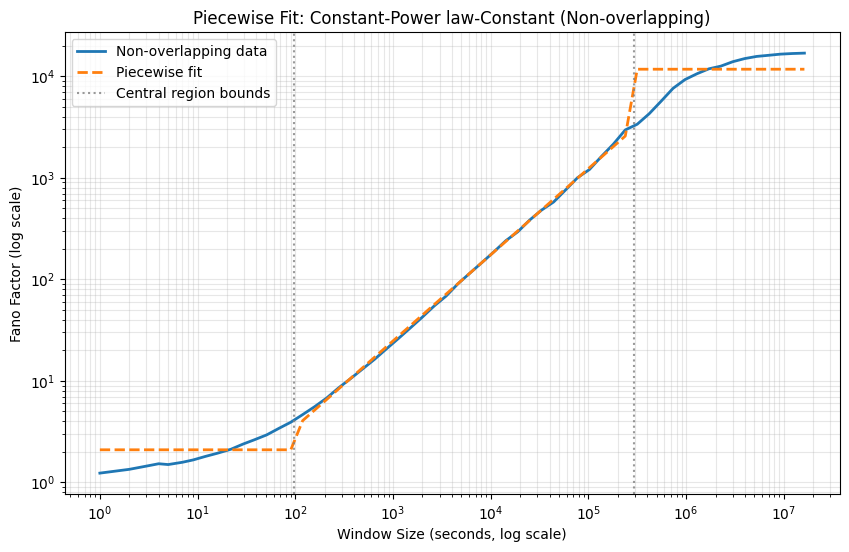

In [6]:
# Piecewise fit on non-overlapping data in seconds:
# small-scale constant, central power law, large-scale constant.
fit_df = comparison_df_clean.copy()
fit_df = fit_df[(fit_df['window_seconds'] > 0) & (fit_df['fano_non_overlapping'] > 0)].copy()

x = fit_df['window_seconds'].to_numpy(dtype=float)
y = fit_df['fano_non_overlapping'].to_numpy(dtype=float)

# Define central scaling region in log-space quantiles (adjust if needed).
logx = np.log10(x)
q_low, q_high = 0.25, 0.75
x_low = 10 ** np.quantile(logx, q_low)
x_high = 10 ** np.quantile(logx, q_high)

small_mask = x < x_low
central_mask = (x >= x_low) & (x <= x_high)
large_mask = x > x_high

# Constants for small and large scales.
c_small = np.nanmean(y[small_mask]) if np.any(small_mask) else np.nan
c_large = np.nanmean(y[large_mask]) if np.any(large_mask) else np.nan

# Power-law fit in central region: F(w) = A * w^alpha
x_c = x[central_mask]
y_c = y[central_mask]
logx_c = np.log10(x_c)
logy_c = np.log10(y_c)
alpha, intercept = np.polyfit(logx_c, logy_c, 1)
A = 10 ** intercept
y_power = A * (x ** alpha)

# Build piecewise prediction.
y_piecewise = np.empty_like(y)
y_piecewise[small_mask] = c_small
y_piecewise[central_mask] = y_power[central_mask]
y_piecewise[large_mask] = c_large

# Goodness-of-fit on positive finite points in log-space.
valid = np.isfinite(y_piecewise) & (y_piecewise > 0)
ss_res = np.sum((np.log10(y[valid]) - np.log10(y_piecewise[valid])) ** 2)
ss_tot = np.sum((np.log10(y[valid]) - np.mean(np.log10(y[valid]))) ** 2)
r2_log = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

print(f"Central-region power law: F(w) = {A:.4g} * w^{alpha:.4f}")
print(f"Small-scale constant (w < {x_low:.0f} s): {c_small:.4f}")
print(f"Large-scale constant (w > {x_high:.0f} s): {c_large:.4f}")
print(f"Piecewise model R^2 in log-log space: {r2_log:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Non-overlapping data', linewidth=2)
plt.plot(x, y_piecewise, '--', label='Piecewise fit', linewidth=2)
plt.axvline(x_low, color='gray', linestyle=':', alpha=0.8, label='Central region bounds')
plt.axvline(x_high, color='gray', linestyle=':', alpha=0.8)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Window Size (seconds, log scale)')
plt.ylabel('Fano Factor (log scale)')
plt.title('Piecewise Fit: Constant-Power law-Constant (Non-overlapping)')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

Central-region power law: F(w) = 0.07021 * w^0.8489
Small-scale constant (w < 97 s): 2.0957
Large-scale constant (w > 294479 s): 11741.1573
Piecewise model R^2 in log-log space: 0.9912


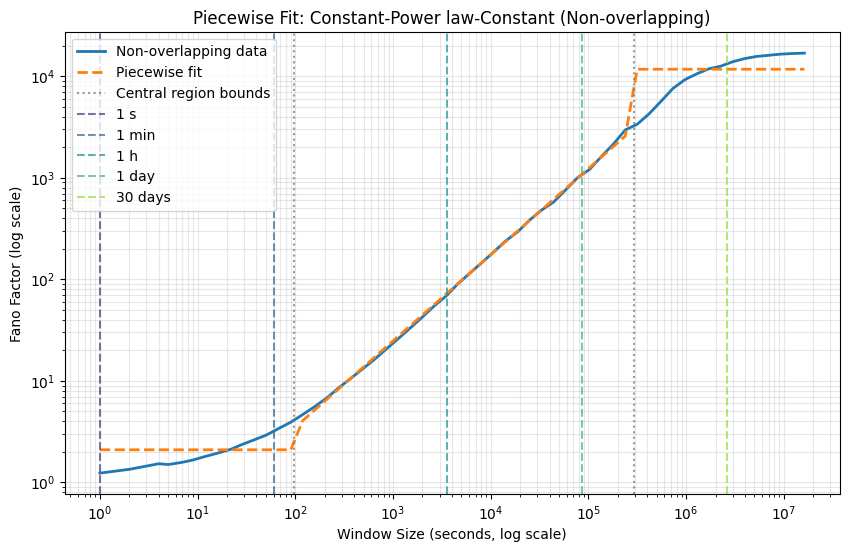

In [7]:
# Piecewise fit on non-overlapping data in seconds:
# small-scale constant, central power law, large-scale constant.
fit_df = comparison_df_clean.copy()
fit_df = fit_df[(fit_df['window_seconds'] > 0) & (fit_df['fano_non_overlapping'] > 0)].copy()

x = fit_df['window_seconds'].to_numpy(dtype=float)
y = fit_df['fano_non_overlapping'].to_numpy(dtype=float)

# Define central scaling region in log-space quantiles (adjust if needed).
logx = np.log10(x)
q_low, q_high = 0.25, 0.75
x_low = 10 ** np.quantile(logx, q_low)
x_high = 10 ** np.quantile(logx, q_high)

small_mask = x < x_low
central_mask = (x >= x_low) & (x <= x_high)
large_mask = x > x_high

# Constants for small and large scales.
c_small = np.nanmean(y[small_mask]) if np.any(small_mask) else np.nan
c_large = np.nanmean(y[large_mask]) if np.any(large_mask) else np.nan

# Power-law fit in central region: F(w) = A * w^alpha
x_c = x[central_mask]
y_c = y[central_mask]
logx_c = np.log10(x_c)
logy_c = np.log10(y_c)
alpha, intercept = np.polyfit(logx_c, logy_c, 1)
A = 10 ** intercept
y_power = A * (x ** alpha)

# Build piecewise prediction.
y_piecewise = np.empty_like(y)
y_piecewise[small_mask] = c_small
y_piecewise[central_mask] = y_power[central_mask]
y_piecewise[large_mask] = c_large

# Goodness-of-fit on positive finite points in log-space.
valid = np.isfinite(y_piecewise) & (y_piecewise > 0)
ss_res = np.sum((np.log10(y[valid]) - np.log10(y_piecewise[valid])) ** 2)
ss_tot = np.sum((np.log10(y[valid]) - np.mean(np.log10(y[valid]))) ** 2)
r2_log = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

# Create vertical lines for different time scales.
time_scales = [
    (1, '1 s'),
    (60, '1 min'),
    (3600, '1 h'),
    (24 * 3600, '1 day'),
    (30 * 24 * 3600, '30 days'),
]
time_scale_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(time_scales)))

print(f"Central-region power law: F(w) = {A:.4g} * w^{alpha:.4f}")
print(f"Small-scale constant (w < {x_low:.0f} s): {c_small:.4f}")
print(f"Large-scale constant (w > {x_high:.0f} s): {c_large:.4f}")
print(f"Piecewise model R^2 in log-log space: {r2_log:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Non-overlapping data', linewidth=2)
plt.plot(x, y_piecewise, '--', label='Piecewise fit', linewidth=2)
plt.axvline(x_low, color='gray', linestyle=':', alpha=0.8, label='Central region bounds')
plt.axvline(x_high, color='gray', linestyle=':', alpha=0.8)
for (time, label), color in zip(time_scales, time_scale_colors):
    if x.min() <= time <= x.max():
        plt.axvline(time, color=color, linestyle='--', alpha=0.7, label=label)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Window Size (seconds, log scale)')
plt.ylabel('Fano Factor (log scale)')
plt.title('Piecewise Fit: Constant-Power law-Constant (Non-overlapping)')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

Central-region power law: F(w) = 0.07015 * w^0.8493
Small-scale constant (w < 97 s): 2.0772
Large-scale constant (w > 294479 s): 5414.4563
Piecewise model R^2 in log-log space: 0.9962


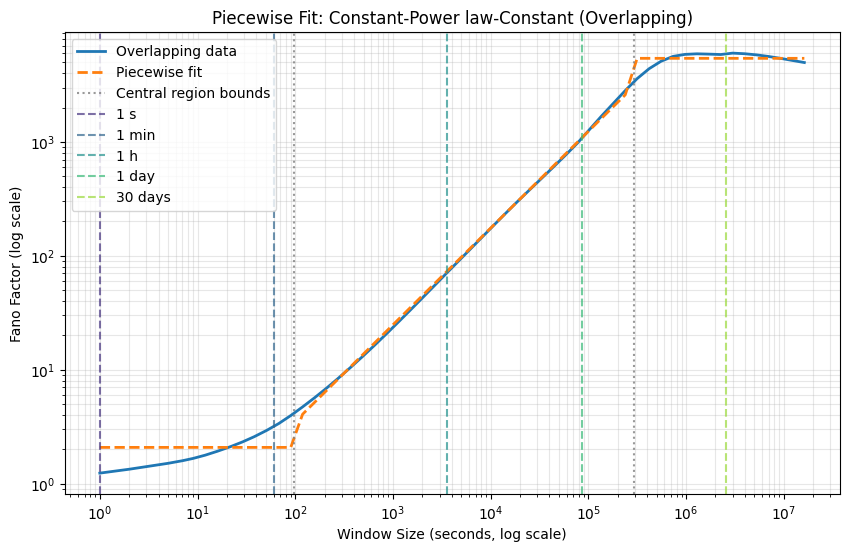

In [8]:
# Piecewise fit on overlapping data in seconds:
# small-scale constant, central power law, large-scale constant.
fit_df = comparison_df_clean.copy()
fit_df = fit_df[(fit_df['window_seconds'] > 0) & (fit_df['fano_overlapping'] > 0)].copy()

x = fit_df['window_seconds'].to_numpy(dtype=float)
y = fit_df['fano_overlapping'].to_numpy(dtype=float)

# Define central scaling region in log-space quantiles (adjust if needed).
logx = np.log10(x)
q_low, q_high = 0.25, 0.75
x_low = 10 ** np.quantile(logx, q_low)
x_high = 10 ** np.quantile(logx, q_high)

small_mask = x < x_low
central_mask = (x >= x_low) & (x <= x_high)
large_mask = x > x_high

# Constants for small and large scales.
c_small = np.nanmean(y[small_mask]) if np.any(small_mask) else np.nan
c_large = np.nanmean(y[large_mask]) if np.any(large_mask) else np.nan

# Power-law fit in central region: F(w) = A * w^alpha
x_c = x[central_mask]
y_c = y[central_mask]
logx_c = np.log10(x_c)
logy_c = np.log10(y_c)
alpha, intercept = np.polyfit(logx_c, logy_c, 1)
A = 10 ** intercept
y_power = A * (x ** alpha)

# Build piecewise prediction.
y_piecewise = np.empty_like(y)
y_piecewise[small_mask] = c_small
y_piecewise[central_mask] = y_power[central_mask]
y_piecewise[large_mask] = c_large

# Goodness-of-fit on positive finite points in log-space.
valid = np.isfinite(y_piecewise) & (y_piecewise > 0)
ss_res = np.sum((np.log10(y[valid]) - np.log10(y_piecewise[valid])) ** 2)
ss_tot = np.sum((np.log10(y[valid]) - np.mean(np.log10(y[valid]))) ** 2)
r2_log = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

# Create vertical lines for different time scales.
time_scales = [
    (1, '1 s'),
    (60, '1 min'),
    (3600, '1 h'),
    (24 * 3600, '1 day'),
    (30 * 24 * 3600, '30 days'),
]
time_scale_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(time_scales)))

print(f"Central-region power law: F(w) = {A:.4g} * w^{alpha:.4f}")
print(f"Small-scale constant (w < {x_low:.0f} s): {c_small:.4f}")
print(f"Large-scale constant (w > {x_high:.0f} s): {c_large:.4f}")
print(f"Piecewise model R^2 in log-log space: {r2_log:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Overlapping data', linewidth=2)
plt.plot(x, y_piecewise, '--', label='Piecewise fit', linewidth=2)
plt.axvline(x_low, color='gray', linestyle=':', alpha=0.8, label='Central region bounds')
plt.axvline(x_high, color='gray', linestyle=':', alpha=0.8)
for (time, label), color in zip(time_scales, time_scale_colors):
    if x.min() <= time <= x.max():
        plt.axvline(time, color=color, linestyle='--', alpha=0.7, label=label)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Window Size (seconds, log scale)')
plt.ylabel('Fano Factor (log scale)')
plt.title('Piecewise Fit: Constant-Power law-Constant (Overlapping)')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

## Per Channel analysis

In [10]:
# Retrieve the data from the different channels
waiting_times_general = df[df['topic_name'] == 'Discusión general']['waiting_time']
waiting_times_bienvenidos = df[df['topic_name'] == 'Bienvenid@s a la Red de Voluntari@s (leed primero)']['waiting_time']
waiting_times_tranporte = df[df['topic_name'] == 'Transporte de personas a Comunidad Valenciana']['waiting_time']
waiting_times_grupos_accion = df[df['topic_name'] == 'Grupos de Acción Voluntarios en Terreno']['waiting_time']
waiting_times_juridica = df[df['topic_name'] == 'Asistencia Jurídica/Seguros']['waiting_time']
waiting_times_tecnica = df[df['topic_name'] == 'Asistencia Técnica y Maquinaria (mecánica, fontanería, electricidad, agricola)']['waiting_time']
waiting_times_animales = df[df['topic_name'] == 'Asistencia animales compañia y otros']['waiting_time']
waiting_times_informatica = df[df['topic_name'] == 'Asistencia Informática/Soporte EAT']['waiting_time']
waiting_times_logistica = df[df['topic_name'] == 'Logística Interna Valencia(puntos de recepción)']['waiting_time']
waiting_times_ayudaempresas = df[df['topic_name'] == 'Ayuda de Empresas']['waiting_time']
waiting_times_investigacion = df[df['topic_name'] == 'Investigación Ciudadana: Responsabilidades Políticas']['waiting_time']
waiting_times_asistencia_voluntarios = df[df['topic_name'] == 'Asistencia a Voluntarios (Comida y Acogida))']['waiting_time']
waiting_times_asistencia_vulnerables = df[df['topic_name'] == 'Asis. Grupos Vulnerables (Maternidad , Infancia, Mayores, etc)']['waiting_time']
waiting_times_material = df[df['topic_name'] == 'Material Video/Fotográfico']['waiting_time']
waiting_times_webs = df[df['topic_name'] == 'Webs Esenciales']['waiting_time']
waiting_times_mensajes_ayuda = df[df['topic_name'] == 'Mensajes de Ayuda (Ofrezco/Necesito)']['waiting_time']
waiting_times_voluntarios_fuera = df[df['topic_name'] == 'Voluntarios de fuera de Valencia (Madrid, Cataluña, Alicante, Castellón)']['waiting_time']
waiting_times_viviendas = df[df['topic_name'] == 'Viviendas Edificación , Muebles y Acondicionamiento']['waiting_time']




In [11]:
# Define a consistent color palette for all channels
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Using tab20 colormap which provides 20 distinct colors
tab20 = cm.get_cmap('tab20')
channel_colors = {
    'General': tab20(0),
    'Bienvenidos': tab20(1),
    'Transporte': tab20(2),
    'Grupos de Acción': tab20(3),
    'Jurídica': tab20(4),
    'Técnica': tab20(5),
    'Animales': tab20(6),
    'Informática': tab20(7),
    'Logística': tab20(8),
    'Ayuda a Empresas': tab20(9),
    'Investigación': tab20(10),
    'Asistencia a Voluntarios': tab20(11),
    'Asistencia a Grupos Vulnerables': tab20(12),
    'Material': tab20(13),
    'Webs': tab20(14),
    'Mensajes de Ayuda': tab20(15),
    'Voluntarios de Fuera': tab20(16),
    'Viviendas': tab20(17)
}

print("Color palette created with 18 distinct colors for all channels")

Color palette created with 18 distinct colors for all channels


C:\Users\Usuario\AppData\Local\Temp\ipykernel_92400\3019095795.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab20 = cm.get_cmap('tab20')


In [14]:
# Obtain the truncated power law fit for the waiting times of the different channels
poll_waiting_times = {
    'General': waiting_times_general,
    'Bienvenidos': waiting_times_bienvenidos,
    'Transporte': waiting_times_tranporte,
    'Grupos de Acción': waiting_times_grupos_accion,
    'Jurídica': waiting_times_juridica,
    'Técnica': waiting_times_tecnica,
    'Animales': waiting_times_animales,
    'Informática': waiting_times_informatica,
    'Logística': waiting_times_logistica,
    'Ayuda a Empresas': waiting_times_ayudaempresas,
    'Investigación': waiting_times_investigacion,
    'Asistencia a Voluntarios': waiting_times_asistencia_voluntarios,
    'Asistencia a Grupos Vulnerables': waiting_times_asistencia_vulnerables,
    'Material': waiting_times_material,
    'Webs': waiting_times_webs,
    'Mensajes de Ayuda': waiting_times_mensajes_ayuda,
    'Voluntarios de Fuera': waiting_times_voluntarios_fuera,
    'Viviendas': waiting_times_viviendas
}
results = {}
for channel, waits in poll_waiting_times.items():
    data = np.asarray(waits.values, dtype=float)
    data = data[np.isfinite(data)]
    data = data[data > 0]
    if len(data) < 1000:
        print(f"Skipping {channel} (not enough data points)")
        continue
    fit = powerlaw.Fit(data, discrete=False, verbose=False)
    tpl = fit.truncated_power_law
    results[channel] = {
        'alpha': getattr(tpl, "alpha", np.nan),
        'lambda': getattr(tpl, "Lambda", np.nan),
        'xmin': getattr(tpl, "xmin", np.nan),
        'sigma': getattr(tpl, "sigma", np.nan),
        'n_tail': int(np.sum(data >= getattr(tpl, "xmin", np.nan))),
        'n_total': len(data)
    }
    print(f"Finished fitting {channel} (n={len(data)})")
    print(f"  alpha: {results[channel]['alpha']:.4f}, lambda: {results[channel]['lambda']:.6f}, xmin: {results[channel]['xmin']:.4f}, sigma: {results[channel]['sigma']:.4f}")





Skipping General (not enough data points)
Finished fitting Bienvenidos (n=2770)
  alpha: 1.6059, lambda: 0.000000, xmin: 18.0000, sigma: nan
Finished fitting Transporte (n=1992)
  alpha: 1.8009, lambda: 0.000006, xmin: 510.0000, sigma: nan
Skipping Grupos de Acción (not enough data points)
Skipping Jurídica (not enough data points)
Skipping Técnica (not enough data points)
Skipping Animales (not enough data points)
Finished fitting Informática (n=1918)
  alpha: 2.0945, lambda: 0.000000, xmin: 32.0000, sigma: nan
Finished fitting Logística (n=1261)
  alpha: 1.4467, lambda: 0.000012, xmin: 52.0000, sigma: nan
Skipping Ayuda a Empresas (not enough data points)
Finished fitting Investigación (n=2684)
  alpha: 1.6427, lambda: 0.000010, xmin: 52.0000, sigma: nan
Finished fitting Asistencia a Voluntarios (n=1128)
  alpha: 1.8890, lambda: 0.000039, xmin: 89.0000, sigma: nan
Skipping Asistencia a Grupos Vulnerables (not enough data points)
Finished fitting Material (n=1021)
  alpha: 1.4983, lam

Skipping General (not enough data points)
Bienvenidos: Fano factor (non-overlapping) = 1.2351
Transporte: Fano factor (non-overlapping) = 1.3187
Skipping Grupos de Acción (not enough data points)
Skipping Jurídica (not enough data points)
Skipping Técnica (not enough data points)
Skipping Animales (not enough data points)
Informática: Fano factor (non-overlapping) = 1.2595
Logística: Fano factor (non-overlapping) = 1.1503
Skipping Ayuda a Empresas (not enough data points)
Investigación: Fano factor (non-overlapping) = 1.1478
Asistencia a Voluntarios: Fano factor (non-overlapping) = 1.1207
Skipping Asistencia a Grupos Vulnerables (not enough data points)
Material: Fano factor (non-overlapping) = 1.1538
Skipping Webs (not enough data points)
Skipping Mensajes de Ayuda (not enough data points)
Skipping Voluntarios de Fuera (not enough data points)
Skipping Viviendas (not enough data points)


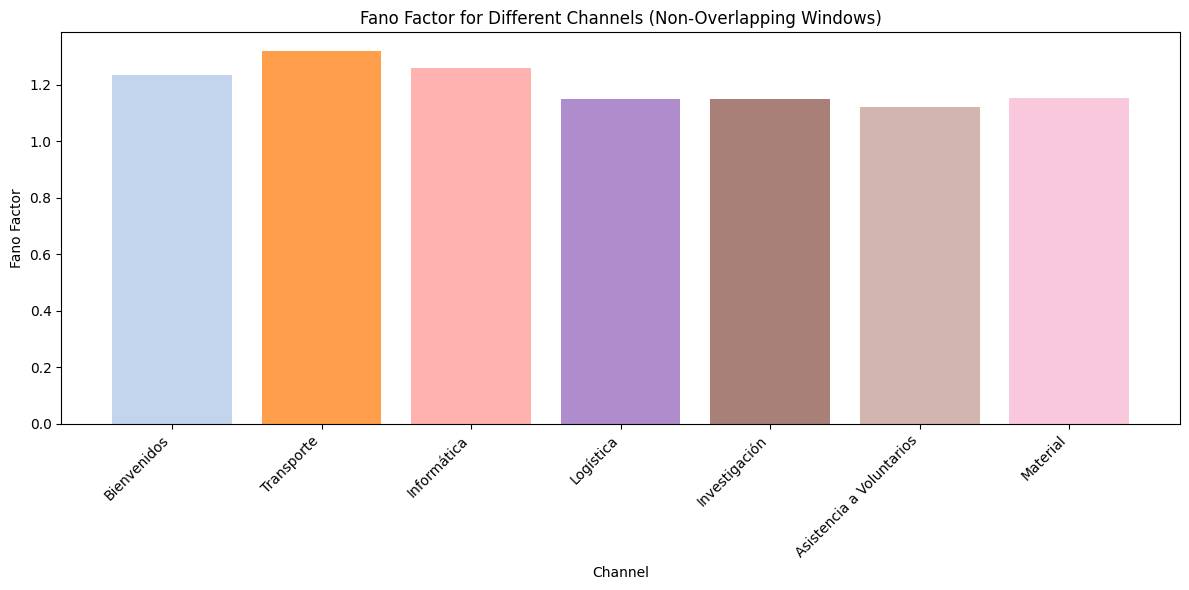

In [17]:
# Fano factor for different channels (non-overlapping windows) for different time scales (seconds, minutes, hours, days, weeks) with a consistent color palette for all channels
bin_size = '1s'  # Base time bin for event counts.
window_bins = 10  # Non-overlapping window length measured in base bins.
channel_fano_factors = {}

for channel, waits in poll_waiting_times.items():
    data = np.asarray(waits.values, dtype=float)
    data = data[np.isfinite(data)]
    data = data[data > 0]

    if len(data) < 1000:
        print(f"Skipping {channel} (not enough data points)")
        continue

    # Convert inter-arrival times (seconds) to synthetic event timestamps.
    event_times = pd.to_timedelta(np.cumsum(data), unit='s')

    # Build event-count time series with a TimedeltaIndex so resample works.
    counts_per_bin = (
        pd.Series(1.0, index=event_times)
        .resample(bin_size)
        .sum()
        .fillna(0.0)
    )

    n_windows = len(counts_per_bin) // window_bins
    if n_windows < 2:
        print(f"Skipping {channel} (not enough bins for Fano factor)")
        continue

    trimmed = counts_per_bin.iloc[: n_windows * window_bins].to_numpy()
    non_overlap_counts = trimmed.reshape(n_windows, window_bins).sum(axis=1)

    mean_count = non_overlap_counts.mean()
    var_count = non_overlap_counts.var(ddof=1)
    fano_factor = var_count / mean_count if mean_count > 0 else np.nan

    channel_fano_factors[channel] = fano_factor
    print(f"{channel}: Fano factor (non-overlapping) = {fano_factor:.4f}")

# Plotting the Fano factors for different channels
plt.figure(figsize=(12, 6))
for channel, fano in channel_fano_factors.items():
    plt.bar(channel, fano, color=channel_colors.get(channel, 'gray'), alpha=0.75)

plt.xlabel('Channel')
plt.ylabel('Fano Factor')
plt.title('Fano Factor for Different Channels (Non-Overlapping Windows)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
# Fano factor analysis across window sizes for all channels with >1000 messages
def compute_fano_across_windows(waiting_times, bin_size='1s', max_windows=60):
    """
    Compute Fano factors across a range of window sizes for a given waiting time series.
    Returns window sizes (in seconds) and corresponding overlapping/non-overlapping Fano factors.
    """
    data = np.asarray(waiting_times.values, dtype=float)
    data = data[np.isfinite(data)]
    data = data[data > 0]
    
    if len(data) < 100:
        return None, None, None, None
    
    # Convert to synthetic event times
    event_times = pd.to_timedelta(np.cumsum(data), unit='s')
    counts_per_bin = (
        pd.Series(1.0, index=event_times)
        .resample(bin_size)
        .sum()
        .fillna(0.0)
    )
    
    if len(counts_per_bin) < 4:
        return None, None, None, None
    
    # Window sizes (in base bins)
    max_window = max(2, len(counts_per_bin) // 2)
    window_sizes = np.unique(
        np.logspace(0, np.log10(max_window), max_windows).astype(int)
    )
    
    fano_overlapping = []
    fano_non_overlapping = []
    valid_windows = []
    
    for window in window_sizes:
        if window < 1:
            continue
        
        # Overlapping windows
        overlap_counts = counts_per_bin.rolling(window=window).sum().dropna()
        mean_overlap = overlap_counts.mean()
        var_overlap = overlap_counts.var(ddof=1) if len(overlap_counts) > 1 else np.nan
        f_overlap = var_overlap / mean_overlap if mean_overlap > 0 else np.nan
        
        # Non-overlapping windows
        n_blocks = len(counts_per_bin) // window
        if n_blocks > 1:
            trimmed = counts_per_bin.iloc[: n_blocks * window].to_numpy()
            non_overlap_counts = trimmed.reshape(n_blocks, window).sum(axis=1)
            mean_non_overlap = non_overlap_counts.mean()
            var_non_overlap = non_overlap_counts.var(ddof=1)
            f_non_overlap = var_non_overlap / mean_non_overlap if mean_non_overlap > 0 else np.nan
        else:
            f_non_overlap = np.nan
        
        valid_windows.append(window)
        fano_overlapping.append(f_overlap)
        fano_non_overlapping.append(f_non_overlap)
    
    window_seconds = np.array(valid_windows)
    return window_seconds, fano_non_overlapping, fano_overlapping, len(data)

# Compute total messages per channel and filter by actual valid events
channel_message_counts = df.groupby('topic_name').size()

# Dynamically filter channels with >1000 actual events (not just messages)
channels_large_short = []
for channel, waiting in poll_waiting_times.items():
    data = np.asarray(waiting.values, dtype=float)
    data = data[np.isfinite(data)]
    data = data[data > 0]
    if len(data) >= 1000:
        channels_large_short.append(channel)

channels_large_short = sorted(channels_large_short)

print(f"Channels with >=1000 valid events: {len(channels_large_short)}")
print(channels_large_short)

# Compute fano factors for each large channel
channel_fano_windows = {}
for channel in channels_large_short:
    if channel not in poll_waiting_times:
        continue
    waiting = poll_waiting_times[channel]
    win_sec, fano_non_o, fano_o, n_events = compute_fano_across_windows(waiting)
    if win_sec is not None:
        channel_fano_windows[channel] = {
            'windows': win_sec,
            'fano_non_overlapping': fano_non_o,
            'fano_overlapping': fano_o,
            'n_events': n_events
        }
        print(f"{channel}: {n_events} events")


Channels with >=1000 valid events: 7
['Asistencia a Voluntarios', 'Bienvenidos', 'Informática', 'Investigación', 'Logística', 'Material', 'Transporte']
Asistencia a Voluntarios: 1128 events
Bienvenidos: 2770 events
Informática: 1918 events
Investigación: 2684 events
Logística: 1261 events
Material: 1021 events
Transporte: 1992 events


Asistencia a Voluntarios: α=0.7001, A=0.1004, R²=0.9485


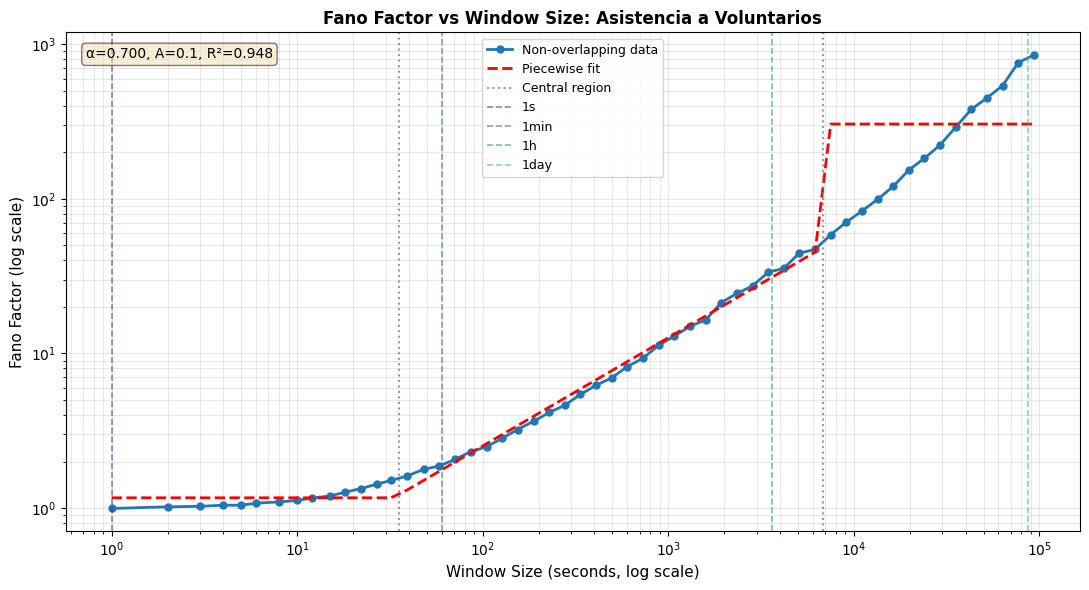

Bienvenidos: α=0.8609, A=0.05972, R²=0.9970


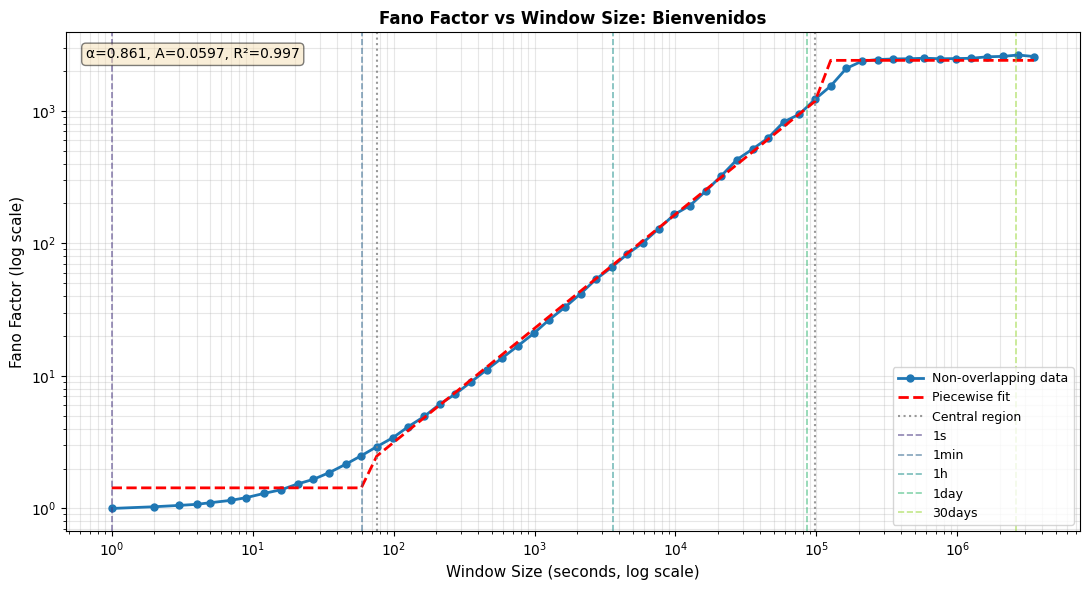

Informática: α=0.8762, A=0.08126, R²=0.9867


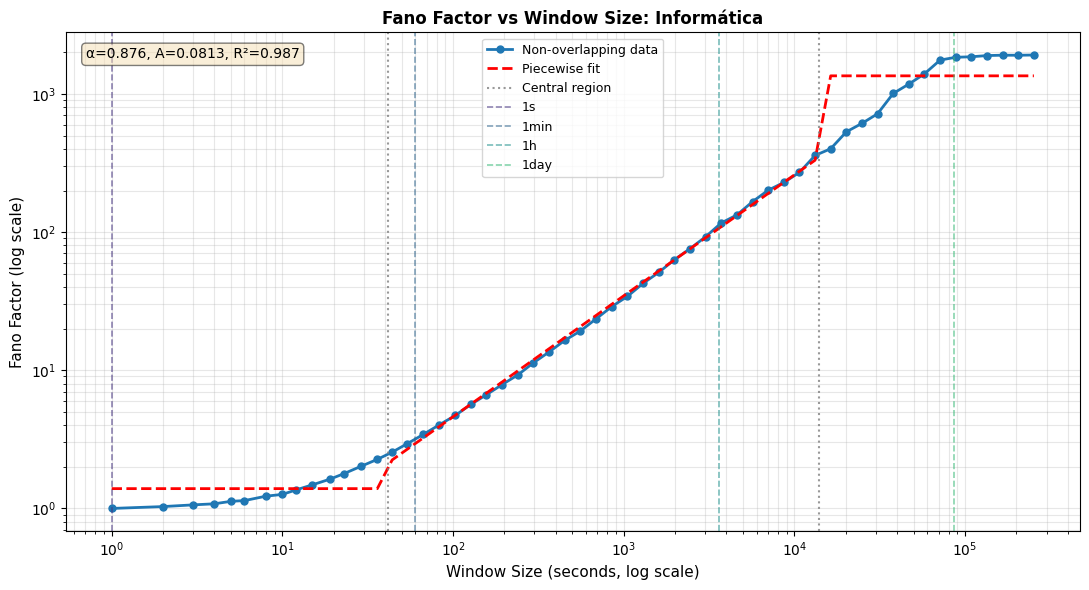

Investigación: α=0.8429, A=0.05599, R²=0.9889


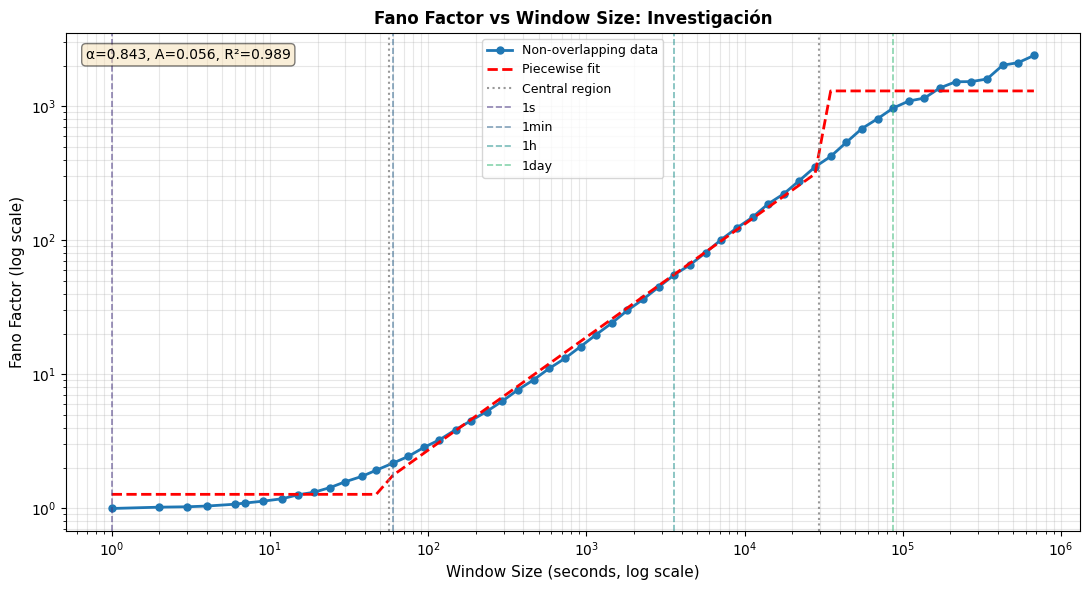

Logística: α=0.7844, A=0.0639, R²=0.9921


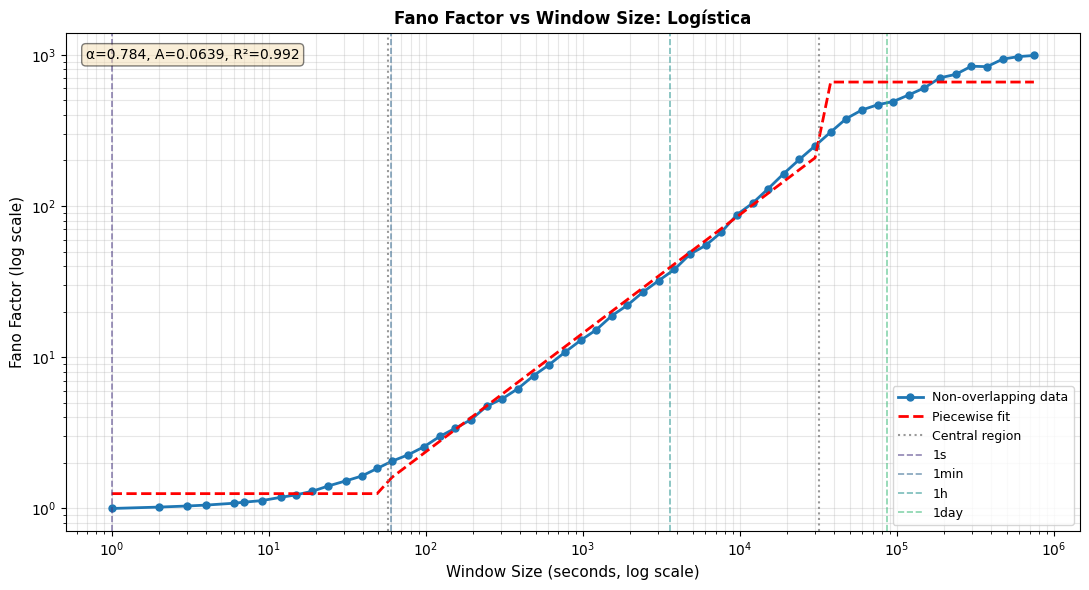

Material: α=0.6988, A=0.07786, R²=0.9872


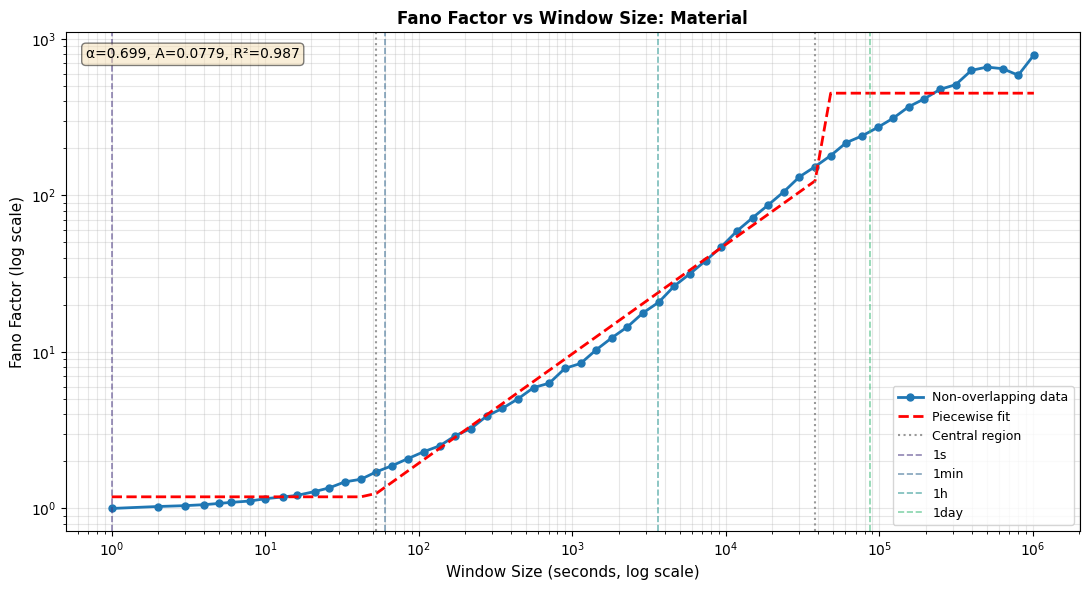

Transporte: α=0.7802, A=0.138, R²=0.9813


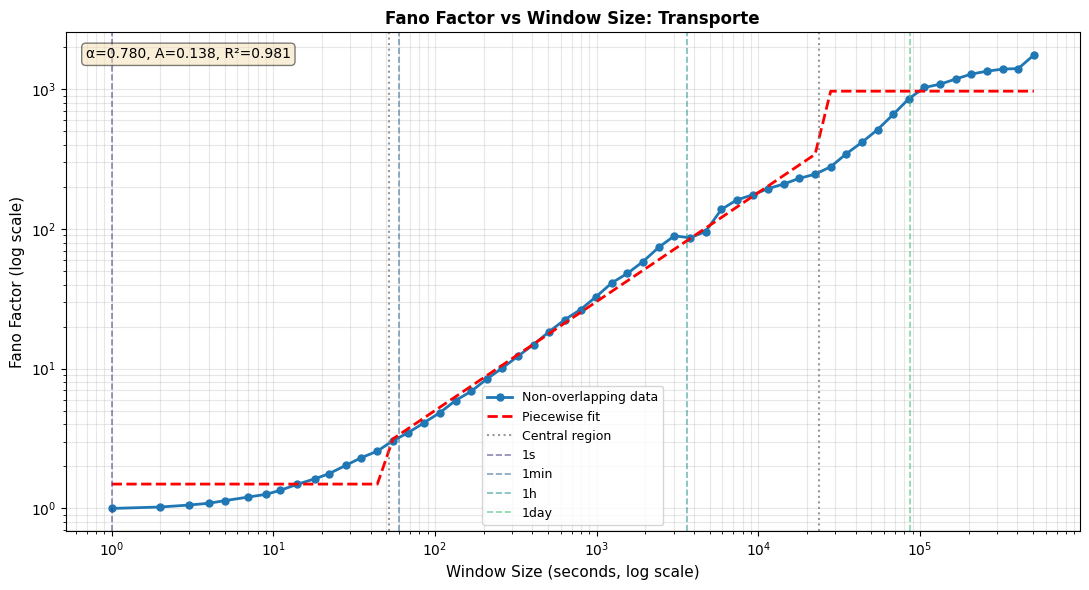


Completed piecewise fits for 7 channels


In [23]:

# Piecewise fit and plotting for each large channel (non-overlapping windows)
def fit_piecewise_fano(window_seconds, fano_values, channel_name):
    """
    Fit piecewise model (constant-power law-constant) to fano factor data.
    Returns fit parameters and a plot figure.
    """
    df_data = pd.DataFrame({
        'window_seconds': window_seconds,
        'fano': fano_values
    })
    df_data = df_data.replace([np.inf, -np.inf], np.nan).dropna()
    df_data = df_data[(df_data['window_seconds'] > 0) & (df_data['fano'] > 0)]
    
    if len(df_data) < 5:
        return None
    
    x = df_data['window_seconds'].to_numpy(dtype=float)
    y = df_data['fano'].to_numpy(dtype=float)
    
    # Define central scaling region
    logx = np.log10(x)
    q_low, q_high = 0.25, 0.75
    x_low = 10 ** np.quantile(logx, q_low)
    x_high = 10 ** np.quantile(logx, q_high)
    
    small_mask = x < x_low
    central_mask = (x >= x_low) & (x <= x_high)
    large_mask = x > x_high
    
    c_small = np.nanmean(y[small_mask]) if np.any(small_mask) else np.nan
    c_large = np.nanmean(y[large_mask]) if np.any(large_mask) else np.nan
    
    # Power law fit in central region
    x_c = x[central_mask]
    y_c = y[central_mask]
    if len(x_c) > 1:
        logx_c = np.log10(x_c)
        logy_c = np.log10(y_c)
        alpha, intercept = np.polyfit(logx_c, logy_c, 1)
        A = 10 ** intercept
    else:
        alpha, A = np.nan, np.nan
    
    # Piecewise prediction
    y_piecewise = np.empty_like(y)
    y_piecewise[small_mask] = c_small
    if not np.isnan(alpha):
        y_piecewise[central_mask] = A * (x[central_mask] ** alpha)
    y_piecewise[large_mask] = c_large
    
    # R^2 in log-log space
    valid = np.isfinite(y_piecewise) & (y_piecewise > 0)
    if np.sum(valid) > 1:
        ss_res = np.sum((np.log10(y[valid]) - np.log10(y_piecewise[valid])) ** 2)
        ss_tot = np.sum((np.log10(y[valid]) - np.mean(np.log10(y[valid]))) ** 2)
        r2_log = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    else:
        r2_log = np.nan
    
    # Time scales
    time_scales = [
        (1, '1s'), (60, '1min'), (3600, '1h'),
        (24*3600, '1day'), (30*24*3600, '30days')
    ]
    time_scale_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(time_scales)))
    
    # Plot
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.plot(x, y, 'o-', label='Non-overlapping data', linewidth=2, markersize=5)
    ax.plot(x, y_piecewise, '--', label='Piecewise fit', linewidth=2, color='red')
    ax.axvline(x_low, color='gray', linestyle=':', alpha=0.8, linewidth=1.5, label='Central region')
    ax.axvline(x_high, color='gray', linestyle=':', alpha=0.8, linewidth=1.5)
    
    for (time_s, label), color in zip(time_scales, time_scale_colors):
        if x.min() <= time_s <= x.max():
            ax.axvline(time_s, color=color, linestyle='--', alpha=0.6, linewidth=1.2, label=label)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Window Size (seconds, log scale)', fontsize=11)
    ax.set_ylabel('Fano Factor (log scale)', fontsize=11)
    ax.set_title(f'Fano Factor vs Window Size: {channel_name}', fontsize=12, fontweight='bold')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=9, loc='best')
    
    info_str = f"α={alpha:.3f}, A={A:.3g}, R²={r2_log:.3f}"
    ax.text(0.02, 0.97, info_str, transform=ax.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    return {
        'alpha': alpha, 'A': A, 'c_small': c_small, 'c_large': c_large,
        'x_low': x_low, 'x_high': x_high, 'r2': r2_log, 'fig': fig
    }

# Generate piecewise fits for all large channels
summary_results = {}
for channel, data in sorted(channel_fano_windows.items()):
    result = fit_piecewise_fano(data['windows'], data['fano_non_overlapping'], channel)
    if result:
        summary_results[channel] = result
        print(f"{channel}: α={result['alpha']:.4f}, A={result['A']:.4g}, R²={result['r2']:.4f}")
        plt.show()

print(f"\nCompleted piecewise fits for {len(summary_results)} channels")


In [24]:

# Summary table of piecewise fits across all channels
summary_table = pd.DataFrame([
    {
        'Channel': ch,
        'α (exponent)': result['alpha'],
        'A (coefficient)': result['A'],
        'c_small': result['c_small'],
        'c_large': result['c_large'],
        'R² (log-log)': result['r2']
    }
    for ch, result in sorted(summary_results.items(), key=lambda x: x[1]['alpha'], reverse=True)
]).round(4)

print("Piecewise Fit Summary (sorted by α, descending):")
print("=" * 100)
display(summary_table)

# Also sort by R² to see fit quality
summary_table_r2 = summary_table.sort_values('R² (log-log)', ascending=False).reset_index(drop=True)
print("\n\nPiecewise Fit Summary (sorted by R², descending - fit quality):")
print("=" * 100)
display(summary_table_r2)


Piecewise Fit Summary (sorted by α, descending):


,Channel,α (exponent),A (coefficient),c_small,c_large,R² (log-log)
0,Informática,0.8762,0.0813,1.3865,1354.3703,0.9867
1,Bienvenidos,0.8609,0.0597,1.4296,2403.4636,0.9970
2,Investigación,0.8429,0.0560,1.2724,1301.1255,0.9889
3,Logística,0.7844,0.0639,1.2525,660.2337,0.9921
4,Transporte,0.7802,0.1380,1.4915,970.4019,0.9813
5,Asistencia a Voluntarios,0.7001,0.1004,1.1651,305.3192,0.9485
6,Material,0.6988,0.0779,1.1860,449.5084,0.9872




Piecewise Fit Summary (sorted by R², descending - fit quality):


,Channel,α (exponent),A (coefficient),c_small,c_large,R² (log-log)
0,Bienvenidos,0.8609,0.0597,1.4296,2403.4636,0.9970
1,Logística,0.7844,0.0639,1.2525,660.2337,0.9921
2,Investigación,0.8429,0.0560,1.2724,1301.1255,0.9889
3,Material,0.6988,0.0779,1.1860,449.5084,0.9872
4,Informática,0.8762,0.0813,1.3865,1354.3703,0.9867
5,Transporte,0.7802,0.1380,1.4915,970.4019,0.9813
6,Asistencia a Voluntarios,0.7001,0.1004,1.1651,305.3192,0.9485
